In [ ]:
#加载数据
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

housing = fetch_california_housing()#housing是个字典
x= housing.data   
y= housing.target 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)#把总样本分为训练集和测试集


In [ ]:
class xianxinghuigui:
    def init (self, method='normal'):#默认指定使用normal算法
        self.quanzhong = None    # 存储权重 w（含截距）
        self.method = method       
    
    def fit(self, x, y):#训练
        #线性回归模型形式为：y = w_0 + w_1 x_1 + ... + w_n x_n
        x_b = np.c_[np.ones((x.shape[0], 1)), x]#假设样本数为m，则np.ones((x.shape[0], 1))就是生成一个m行1列的数组，且元素全是1
        #然后把这些全是1的数组和x合并起来，就是x_b
        #这样构造是为了保证回归模型中的w_0存在，从而使拟合更好
        self.quanzhong = np.linalg.inv(x_b.T.dot(x_b)).dot(x_b.T).dot(y)  # 正规方程：w = (X^T X)^{-1} X^T y 
    
    def predict(self, x):#预测未学习的样本，检查拟合效果
        x_b = np.c_[np.ones((x.shape[0], 1)), x]
        return x_b.dot(self.quanzhong)
    
    def score(self, x, y):
        y_predicted = self.predict(x)    
        # 返回 R² 决定系数
        a = np.sum((y - y_predicted) ** 2)
        b = np.sum((y - np.mean(y)) ** 2)
        return 1 - a / b

In [21]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model = xianxinghuigui()   # 默认 normal 法
model.fit(x_train_scaled, y_train)

print("训练集 R^2:", model.score(x_train_scaled, y_train))
print("测试集 R^2:", model.score(x_test_scaled, y_test))

训练集 R^2: 0.6125511913966952
测试集 R^2: 0.5757877060324512


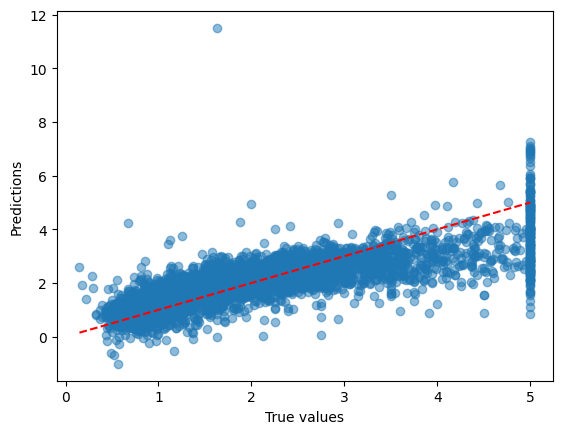

In [17]:
y_pred = model.predict(x_test_scaled)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("True values")
plt.ylabel("Predictions")
plt.show()